# Introduction to Dask Distributed

<img src="https://docs.dask.org/en/latest/_images/dask_horizontal.svg"
     align="right"
     width="20%"
     alt="Dask logo\">

Dask is an open-source Python library for parallel computing. Dask can scale Python code from multi-core local machines to large distributed clusters, without the code having to be altered a great deal. Dask provides a familiar user interface by mirroring the APIs of other libraries in Python, such as pandas and NumPy. It also enables programmers to run custom algorithms in parallel. It does so by creating lazy, delayed objects. These objects hold the "recipe" of how to compute a certain task, without actually performing the computation. These objects are saved in memory as task graphs, wich can be visualized to get a better handle on the actual parallelisaton that is taking place. To actually get the desired numerical result, the task graph has to be passed on to a task scheduler which then performs the computation in parallel.
<br>
<br>
<br>
    
<img src="images/dask-overview.svg" align="center" width="60%">

High level collections are used to generate task graphs which can be executed by schedulers on a single machine or a cluster. Source: https://docs.dask.org/en/stable/10-minutes-to-dask.html

## Dask cluster overview

In this section we'll discuss:

1. The different components which make up a Dask cluster
2. Survey different ways to launch a cluster

### Components of a Dask cluster

A Dask cluster is composed of three different types of objects:

1. **Scheduler**: A single, centralized scheduler process which responds to requests for computations, maintains relavant state about tasks and worker, and sends tasks to workers to be computed.
2. **Workers**: One or more worker processes which compute tasks and store/serve their results.
3. **Clients**: One or more client objects which are the user-facing entry point to interact with the cluster.

<img src="images/dask-cluster.png"
     width="70%"
     alt="Dask components\">
     

### Nodes on Vienna Scientific Cluster

On VSC we have login nodes on which users prepare their job scripts etc. but do not perform expensive computations. For that a HPC cluster has compute nodes which are allocated by the resource manager (in this case SLURM). To access the login nodes you need to SSH from the command line. Alternatively, we can access the VSC via JupyterHub (what we are doing right now). VCS users can get resources for JupyterHub of one node max. To get more compute power we need to submit a job script, just as on a login node.
<br>
<br>
<br>
<img src="images/VSC_Cluster.png"
     width=50%
     alt="Nodes of VSC\"
     align="center">
<br>
<br>
    

### Setting up the ports for communication

This step is necessary, since we are many users each trying to setup our own Dask client to launch workers from and monitor them with the diagnostic tools the Dask dashboard offers. Since we run into trouble when some of us are using the same port, we came up with the Python code below, to ensure we are not getting in each other's way. You do not need this step when working on your local machine.

In [1]:
import os
import dask
import dask.config
import dask.distributed 

In [2]:
try: client
except NameError: client = None

if client is None:
    pass
    
else:
    client.close()
    client = None

In [7]:
try: cluster
except NameError: cluster = None

if cluster is None:
    pass
    
else:
    cluster.close()
    cluster = None

In [8]:
USER = os.environ.get("USER")
if USER.startswith('trainee'):
    user_number = int(USER.replace('trainee', ''))
else:
    user_number = 100

# We all need different ports for our dashboards and schedulers.
DASHBOARD_PORT = 45000 + user_number 
SCHEDULER_PORT = 46000 + user_number
#####

dask.config.set({'temporary_directory': f'/tmp/dask-{USER}'})

dask.config.set({"distributed.dashboard.link": f"/user/{USER}/proxy/{DASHBOARD_PORT}/status"})
print('dashboard link: ', dask.config.get("distributed.dashboard.link"))

dashboard link:  /user/cvargas/proxy/45100/status


### Distributed scheduler on a local machine

The `dask.distributed` system is composed of a single centralized scheduler and one or more worker processes. [Deploying](https://docs.dask.org/en/latest/setup.html) a remote Dask cluster involves some additional effort. But doing things locally it just involves creating a `Client` object, which lets you interact with the "cluster" (local threads or processes on your machine). For more information see [here](https://docs.dask.org/en/latest/setup/single-distributed.html). 

You could create a Dask cluster on your own PC, however, in this case we are on a node running on VSC's JupyterHub. With LocalCluster, you only use the resources avaliable to you on the specific node (machine) you are on. If you want to access more compute power on the VSC by submitting jobs to SLURM (resource manager on VSC), you need Dask's SLURMCluster (see further down). 

In [9]:
from dask.distributed import LocalCluster

# Launch a scheduler and 4 workers on my local machine
cluster = LocalCluster(n_workers=8, threads_per_worker=2, scheduler_port=SCHEDULER_PORT, dashboard_address=DASHBOARD_PORT)
cluster

LocalCluster(97a32121, 'tcp://127.0.0.1:46100', workers=8, threads=16, memory=46.75 GiB)

In [10]:
from dask.distributed import Client

client = Client(cluster)

In [11]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cvargas/proxy/45100/status,
Dashboard: /user/cvargas/proxy/45100/status,Workers: 8
Total threads: 16,Total memory: 46.75 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46100,Workers: 8
Dashboard: /user/cvargas/proxy/45100/status,Total threads: 16
Started: Just now,Total memory: 46.75 GiB
Comm: tcp://127.0.0.1:43071,Total threads: 2
Dashboard: /user/cvargas/proxy/45100/status,Memory: 5.84 GiB
Nanny: tcp://127.0.0.1:37089,


In [12]:
# Scale up to 10 workers
cluster.scale(20)

In [13]:
# Scale down to 2 workers
cluster.scale(1)

In [14]:
# Retrieve cluster logs
cluster.get_logs()

{'Cluster': '',
 'Scheduler': "2024-10-03 21:45:44,716 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:39955', name: 19, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.716091')\n2024-10-03 21:45:44,713 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:33879', name: 18, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.71299')\n2024-10-03 21:45:44,710 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:41735', name: 16, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.710411')\n2024-10-03 21:45:44,710 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:45729', name: 17, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7101457')\n2024-10-03 21:45:44,709 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:41875', name: 15, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.70986')\n2024-10-03 21:45:44,709 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:35659', name: 14, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7095525')\n2024-10-03 21:45:44,709 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:38707', name: 13, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7092266')\n2024-10-03 21:45:44,709 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:40127', name: 10, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7089684')\n2024-10-03 21:45:44,708 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:39421', name: 12, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7087247')\n2024-10-03 21:45:44,708 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:40545', name: 9, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7084727')\n2024-10-03 21:45:44,708 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:43861', name: 11, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7082052')\n2024-10-03 21:45:44,707 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:33353', name: 8, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7079294')\n2024-10-03 21:45:44,707 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:38397', name: 7, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.707656')\n2024-10-03 21:45:44,707 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:42985', name: 6, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7073226')\n2024-10-03 21:45:44,707 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:33919', name: 2, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7070417')\n2024-10-03 21:45:44,706 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:37985', name: 4, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7067482')\n2024-10-03 21:45:44,706 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:42117', name: 5, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.706399')\n2024-10-03 21:45:44,706 - distributed.scheduler - INFO - Remove worker <WorkerState 'tcp://127.0.0.1:45177', name: 3, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1727984744.7059426')\n2024-10-03 21:45:44,705 -

In [18]:
# Caution is required when scaling on a cluster.
# Dask might terminate a worker at a memory use which is too high.
# To change that, modify ~/.config/dask/distributed.yaml accordingly.

from dask.distributed import system

print("RAM:", round(system.MEMORY_LIMIT/1024/1024/1024, 2), "GB")

RAM: 46.75 GB


In [19]:
try: client
except NameError: client = None

if client is None:
    pass
    
else:
    client.close()
    client = None

In [25]:
try: cluster
except NameError: cluster = None

if cluster is None:
    pass
    
else:
    cluster.close()
    cluster = None

### Distributed scheduler on a remote machine

There are several projects in the Dask ecosystem for easily deploying clusters on commonly used computing resources:

- [Dask-Kubernetes](https://kubernetes.dask.org/en/latest/) for deploying Dask using native Kubernetes APIs
- [Dask-Cloudprovider](https://cloudprovider.dask.org/en/latest/) for deploying Dask clusters on various cloud platforms (e.g. AWS, GCP, Azure, etc.)
- [Dask-Yarn](https://yarn.dask.org/en/latest/) for deploying Dask on YARN clusters
- [Dask-MPI](http://mpi.dask.org/en/latest/) for deploying Dask on existing MPI environments
- [Dask-Jobqueue](https://jobqueue.dask.org/en/latest/) for deploying Dask on job queuing systems (e.g. PBS, Slurm, etc.)

Launching clusters with any of these projects follows a similar pattern as using Dask's built-in `LocalCluster`:

```python
# Launch a Dask cluster on a Kubernetes cluster
from dask_kubernetes import KubeCluster
cluster = KubeCluster(...)

# Launch a Dask cluster on AWS Fargate
from dask_cloudprovider.aws import FargateCluster
cluster = FargateCluster(...)

# Launch a Dask cluster on a Slurm job queueing system
from dask_jobqueue import SLURMCluster
cluster = SLURMCluster(...)
```

#### Related Documentation

- [Cluster setup](https://docs.dask.org/en/latest/setup.html)

Now we need to specify the hardware we want for our cluster. Note that the cores and memory are just what you want from one node. Later we will scale that to our requirements. As we would like to get through the SLURM queue as quickly as possible, it makes sense to use fewer cores and memory and and set a shorter walltime for each worker, but then scale the number of workers accordingly.

This is an example of the WIKI Documentation

In [1]:
##########################################################################
# if you are running on a shared node it is important to setup some dask variables
# to not prevent interfering with other users dask setups (e.g. dashboard port ...)
 
import os
import dask
import dask.config
import dask.distributed

try: client
except NameError: client = None

if client is None:
    pass
else:
    client.close()
    client = None

try: cluster
except NameError: cluster = None

if cluster is None:
    pass
    
else:
    cluster.close()
    cluster = None

In [2]:
USER = os.environ.get('USER')

if USER.startswith('trainee'):
    user_number = int(USER.replace('trainee', ''))
else:
    user_number = hash(USER) % 100
print('user_number:', user_number)
 
DASHBOARD_PORT = 45000 + user_number 
SCHEDULER_PORT = 46000 + user_number
###########################################################################
 
print('dashboard port:', DASHBOARD_PORT)
print('scheduler port:', SCHEDULER_PORT)
 
dask.config.set({'temporary_directory': f'/tmp/dask-{USER}'})
print('temporary directory:', dask.config.get('temporary_directory'))
 
dask.config.set({'distributed.dashboard.link': f'/user/{USER}/proxy/{DASHBOARD_PORT}/status'})
print('dashboard link:', dask.config.get('distributed.dashboard.link'))

user_number: 82
dashboard port: 45082
scheduler port: 46082
temporary directory: /tmp/dask-cvargas
dashboard link: /user/cvargas/proxy/45082/status


In [3]:
from dask_jobqueue import SLURMCluster
 
cluster = SLURMCluster(queue='skylake_0096',   # the slurm partition we want to use for dask-worker processes
                       # account='p70824',      # the account (=VSC project) used for accounting
                       account='p72552',      # the account (=VSC project) used for accounting
                       cores=16,               # number of physical processor cores per SLURM job
                       memory='4GB',           # memory one SLURM job should have avaliable (will be divided by number of worker processes in job)
                       processes=2,            # number of dask-worker processes (=python processes) per SLURM job
                       name=f'{USER}-worker',  # custom name of dask-workers (used in dask internally)
                       walltime='00:30:00',    # time a SLURM job will run for e.g. 30 minutes; after that all dask-worker in the job will shutdown
                       interface='lo',        # ib0 is the name of the fast network connection on VSC-4 & VSC-5
                       # interface='ib0',        # ib0 is the name of the fast network connection on VSC-4 & VSC-5
                       scheduler_options={
                           'interface': 'lo',                          # scheduler should also use ib0
                           # 'interface': 'ib0',                          # scheduler should also use ib0
                           'port': SCHEDULER_PORT,                      # custom scheduler port (dask-worker processes will use this to connect)
                           'dashboard_address': f':{DASHBOARD_PORT}',   # custom dashboard port from earlier
                       },
                       # if you use adaptive scaling you might want to set these as well
                       # see https://jobqueue.dask.org/en/latest/advanced-tips-and-tricks.html#how-to-handle-job-queueing-system-walltime-killing-workers
                       #worker_extra_args=[
                       #    '--lifetime', '25m',
                       #    '--lifetime-stagger', '5m'
                       #],
                       job_directives_skip=[
                           '-J dask-worker',              # skip the default SLURM job name
                       ],
                       job_extra_directives=[
                           f'--job-name={USER}-worker',   # set a custom SLURM job name
                           '--qos=skylake_0096',          # set e.g. a custom qos that provides you with faster scheduling
                           #'--reservation=training',     # an optional reservation to use                      
                       ]) 
 
# the settings from above are turned into a slurm job script that can be
# displayed for debugging by using the 'job_script' method
print(cluster.job_script()) 

#!/usr/bin/env bash

#SBATCH -p skylake_0096
#SBATCH -A p72552
#SBATCH -n 1
#SBATCH --cpus-per-task=16
#SBATCH --mem=4G
#SBATCH -t 00:30:00
#SBATCH --job-name=cvargas-worker
#SBATCH --qos=skylake_0096

/home/cvargas/miniconda3/envs/pyforest/bin/python -m distributed.cli.dask_worker tcp://127.0.0.1:46082 --name dummy-name --nthreads 8 --memory-limit 1.86GiB --nworkers 2 --nanny --death-timeout 60 --interface lo



In [20]:
# use 'scale' to schedule a fixed number of slurm jobs that host dask-worker processes
cluster.scale(jobs=2) # depends on sbatch SLURM
 
# OR use 'adapt' to use adaptive scaling
#cluster.adapt(minimum_jobs=1, maximum_jobs=10)
 
# call the 'get_logs' function to see if everything is ok
cluster.get_logs()

{'Cluster': '',
 'Scheduler': "2024-10-03 23:20:03,622 - distributed.scheduler - INFO - Retire worker addresses ('cvargas-worker-7', 'cvargas-worker-5', 'cvargas-worker-2')\n2024-10-03 23:19:52,140 - distributed.scheduler - INFO - Retire worker addresses ('cvargas-worker-0', 'cvargas-worker-6', 'cvargas-worker-8', 'cvargas-worker-9', 'cvargas-worker-1', 'cvargas-worker-4')\n2024-10-03 23:18:23,556 - distributed.scheduler - INFO - Registering Worker plugin shuffle\n2024-10-03 23:18:23,556 - distributed.scheduler - INFO -   dashboard at:  /user/cvargas/proxy/45082/status\n2024-10-03 23:18:23,556 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:46082\n2024-10-03 23:18:23,551 - distributed.scheduler - INFO - State start"}

In [21]:
import dask.array as da

x = da.random.random((1000, 1000, 10), chunks=(1000, 1000, 5))
y = da.random.random((1000, 1000, 10), chunks=(1000, 1000, 5))
z = (da.arcsin(x) + da.arccos(y)).sum(axis=(1,))

z.compute()

array([[1590.24208536, 1549.12870371, 1586.2219919 , ..., 1564.67661184,
        1556.52813042, 1577.11134858],
       [1595.27246237, 1556.51017071, 1569.20157382, ..., 1572.13238388,
        1552.8741324 , 1544.12172989],
       [1566.41954749, 1590.13513238, 1583.49994571, ..., 1570.41665226,
        1584.45784629, 1570.45825701],
       ...,
       [1602.34106851, 1561.5215943 , 1603.05593487, ..., 1574.31277879,
        1564.20343463, 1577.50220024],
       [1577.12754735, 1571.74695237, 1553.20619607, ..., 1583.58378529,
        1577.29408466, 1601.65855167],
       [1555.04289851, 1549.02813231, 1575.45325793, ..., 1578.71314026,
        1532.03760576, 1578.09700828]])

In [ ]:
print("next one is another example")


In [ ]:
print("next one is another example")


In [16]:
print("next one is another example")

next one is another example


In [ ]:
client.close()
del client
cluster.close()
del cluster

In [24]:
from dask_jobqueue import SLURMCluster
cluster = SLURMCluster(queue= "skylake_0096", #"zen3_0512", # this is the partition we want to use
                       account="p72552", # this is the account used for billing
                       #account="p71550",
                       cores=20,          # number of cores per SLURM job
                       processes=1,      # number of python dask-worker processes per SLURM job
                       name=f'{USER}-worker',  # custom name of workers
                       memory="4GB",     # memory one SLURM job should have avaliable (will be divided by number of worker processes in job)
                       walltime="00:05:00",
                       interface="ib0",  # ib0 is infiniband, the fast network connection
                       scheduler_options={
                           "interface": "lo", # "ib0"
                           "dashboard_address": f":{DASHBOARD_PORT}",
                           "port": SCHEDULER_PORT
                       },
                       # worker_extra_args=["--lifetime", "4m", "--lifetime-stagger", "2m"],
                       # lifetime ensures that workers will be properly shut down before the scheduling system kills them, and all their states moved.
                       # lifetime-stagger will prevent workers from terminating at the same time, thus ease rebalancing tasks and scheduling burden.
                       job_directives_skip=[
                           '-J dask-worker',
                       ],
                       job_extra_directives=[
                           f'--job-name={USER}-worker',
                           '--qos=skylake_0096',
                           # '--reservation=vsctraining_jupyterhub_3', # only to be used during this training                          
                       ]) 
print(cluster.job_script()) # this is turned into a job script

/home/cvargas/miniconda3/envs/pyforest/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 45060 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40589 instead
  warnings.warn(


ValueError: cannot get address of non-running Server

In [23]:
import dask.array as da

x = da.random.random((1000, 1000, 10), chunks=(1000, 1000, 5))
y = da.random.random((1000, 1000, 10), chunks=(1000, 1000, 5))
z = (da.arcsin(x) + da.arccos(y)).sum(axis=(1,))

z.compute()

array([[1606.34131639, 1578.26859127, 1562.53751606, ..., 1550.04299959,
        1574.08638499, 1591.39942036],
       [1567.85437055, 1591.26700002, 1579.83012567, ..., 1580.13399699,
        1548.22424259, 1562.43236763],
       [1569.69057384, 1555.86434835, 1596.55864742, ..., 1588.7851946 ,
        1553.44964159, 1567.71761733],
       ...,
       [1614.92026217, 1594.73815254, 1568.13763708, ..., 1568.04092641,
        1585.52738916, 1558.63778136],
       [1590.17371955, 1582.92567042, 1568.0919636 , ..., 1566.09602855,
        1558.4987375 , 1562.69398467],
       [1548.2737527 , 1575.24000773, 1591.90322951, ..., 1568.28658023,
        1575.58768878, 1566.44560606]])

In [27]:
from dask.distributed import Client
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /user/cvargas/proxy/45100/status,
Dashboard: /user/cvargas/proxy/45100/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://127.0.0.1:46100,Workers: 0
Dashboard: /user/cvargas/proxy/45100/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B


In [28]:
cluster.scale(jobs=10)   # starts slurm jobs with dask workers in them

In [29]:
!squeue -u $USER

zsh:1: command not found: squeue


Most Dask deployments are static with a single scheduler and a fixed number of workers. This results in predictable behavior, but is wasteful of resources in two situations:

* The user may not be using the cluster, or perhaps they are busy interpreting a recent result or plot, and so the workers sit idly, taking up valuable shared resources from other potential users

* The user may be very active, and is limited by their original allocation.

Adaptive deployments are particularly helpful for interactive workloads, which are characterized by long periods of inactivity interrupted with short bursts of heavy activity. They can result in both faster analyses that give users much more power, but with much less pressure on computational resources.

<br>
<br>
<br>
<img src="./images/dask-adaptive.svg"
     width=50%
     alt="Nodes of VSC\"
     align="center">
<br>

The theory behind the adaptive cluster is good, but it has to be said, that this doesn't work very well on an HPC system with a job scheduler like Slurm. What is usually does, is making sure that the minimum amount of workers is deployed.

In [ ]:
cluster.adapt(minimum=10, maximum=20)  # scale between 10 and 20 workers

In [51]:
!squeue -u $USER # It might take some time for the jobs to become visible.

             JOBID            PARTITION     NAME     USER ST       TIME  NODES     NODELIST(REASON)
           1582755      zen2_0256_a40x2 vsc5_jh_ trainee9  R    5:18:03      1            n3066-010
           1602388            zen3_0512 trainee9 trainee9  R       0:47      1            n3501-005
           1602390            zen3_0512 trainee9 trainee9  R       0:47      1            n3501-005
           1602384            zen3_0512 trainee9 trainee9  R       0:52      1            n3501-005
           1602386            zen3_0512 trainee9 trainee9  R       0:52      1            n3501-005
           1602380            zen3_0512 trainee9 trainee9  R       0:56      1            n3501-004
           1602382            zen3_0512 trainee9 trainee9  R       0:56      1            n3501-004
           1602373            zen3_0512 trainee9 trainee9  R       1:01      1            n3501-004
           1602376            zen3_0512 trainee9 trainee9  R       1:01      1            n3501-004


### Executing with the distributed client
Let's see what our dask cluster can achieve with this computationally challenging calculation. Note that you might have to wait until sufficient workers are running in the queue.

In [32]:
import dask.array as da

In [50]:
x = da.random.random((10_000,10_000,10), chunks=(1000,250,5))
y = da.random.random((10_000,10_000,10), chunks=(1000,250,5))
z = (da.arcsin(x) + da.arccos(y)).sum(axis=(1,))

In [48]:
x

dask.array<random_sample, shape=(10000, 10000, 10), dtype=float64, chunksize=(1000, 2500, 5), chunktype=numpy.ndarray>

In [52]:
%%time
z.compute()

CPU times: user 1.82 s, sys: 39.3 ms, total: 1.86 s
Wall time: 1.96 s


array([[15673.64719696, 15571.57638653, 15747.26552985, ...,
        15649.10623372, 15707.95770362, 15589.06067674],
       [15657.11476434, 15721.97474372, 15722.67016772, ...,
        15692.33119937, 15826.94907951, 15606.54867848],
       [15710.61596138, 15698.39746411, 15690.71131615, ...,
        15724.79501232, 15661.03483508, 15800.18298799],
       ...,
       [15746.90812647, 15679.63879773, 15808.88256306, ...,
        15658.04157981, 15905.89186265, 15622.47814446],
       [15740.14087175, 15806.77180905, 15696.56085683, ...,
        15733.22380058, 15726.7318669 , 15710.58047746],
       [15721.18000104, 15660.165112  , 15607.07748709, ...,
        15688.6781946 , 15723.86882176, 15772.10506438]])

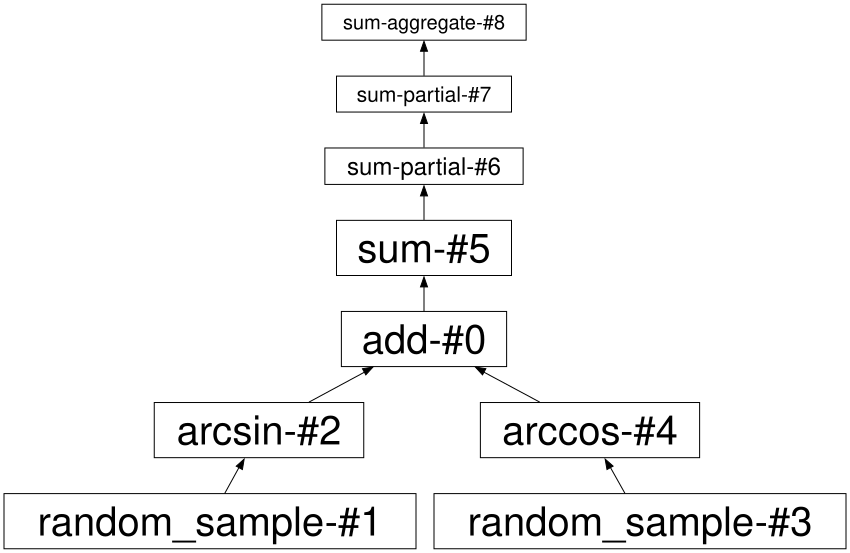

In [36]:
z.dask.visualize() # High level graph. Low level graph with z.visualize(), but this would be overwhelming

By default, creating a `Client` makes it the default scheduler. Any calls to `.compute` will use the cluster your `client` is attached to, unless you specify otherwise, as above.


### Futures

Futures are non-blocking, distributed computations.
They are eager instead of lazy. This means that computation start immediately after a function is submitted, provided that the compute resources are available.
It is possible to submit functions for evaluation with submit() and map(). The call returns immediately, giving one or more futures, whose status begins as “pending” and later becomes “finished”. There is no blocking of the local Python session.

In [53]:
def inc(x):
    return x + 1

def add(x, y):
    return x + y

Submit the functions to the client:

In [71]:
a = client.submit(inc, 10)  # calls inc(10) in background process
b = client.submit(inc, 20)

In [72]:
a

<Future: finished, type: int, key: inc-8e1df8e7e5882accb6a5e34428bc7ae3>

This variable is now a future object.

To retrieve the result, we have to call `future.result()`:

In [73]:
a.result()

11

In [74]:
c = client.submit(add, a, b)

In [75]:
c

<Future: finished, type: int, key: add-e657c6829696f93015bfc1aa5455f195>

In [76]:
c.result()

32

In [77]:
import numpy as np

In [78]:
arr = np.arange(1,15,2)

We can use `client.map`to apply a function to arrays.

In [79]:
map_arr = client.map(inc, arr)

In [80]:
map_arr

[<Future: finished, type: numpy.int64, key: inc-c1a7df19a4636e07894becf70c70bf09>,
 <Future: finished, type: numpy.int64, key: inc-43cae715137412db3144a83a80aafec2>,
 <Future: finished, type: numpy.int64, key: inc-03b0e6a9bc6ed76fc48c261d9984216a>,
 <Future: finished, type: numpy.int64, key: inc-69948442985eb9654714752ceae21285>,
 <Future: finished, type: numpy.int64, key: inc-335aae175628e622af95dd24c3b0128c>,
 <Future: finished, type: numpy.int64, key: inc-39ffd3ad4e86d81ccb1f0753d75f1905>,
 <Future: finished, type: numpy.int64, key: inc-74bb61344acd91a6d1a59f5f5b454ff2>]

We cannot get the result with the method above, because we now have several future objects:

In [81]:
map_arr.result()

AttributeError: 'list' object has no attribute 'result'

Instead we have to use `client.gather(futures)`to retrieve the desired result.

In [82]:
client.gather(map_arr)

[2, 4, 6, 8, 10, 12, 14]

Alternatively, we can scatter an array (or dataframe) across the cluster, then submit a function and get the result back to the host.

In [83]:
remote_arr = client.scatter(arr)

In [84]:
func_arr = client.submit(inc, remote_arr)

In [85]:
func_arr.result()

array([ 2,  4,  6,  8, 10, 12, 14])

In [86]:
import time

In [87]:
arr_2 = np.arange(0, 10_000,1).reshape(100,100)

Using this technique is a great way if your problem is memory-bound, however, if your problem fits in local memory, simple Numpy is much faster.

In [88]:
%%time
np.sin(arr_2)

CPU times: user 1.4 ms, sys: 0 ns, total: 1.4 ms
Wall time: 1.06 ms


array([[ 0.        ,  0.84147098,  0.90929743, ...,  0.37960774,
        -0.57338187, -0.99920683],
       [-0.50636564,  0.45202579,  0.99482679, ...,  0.79580584,
        -0.07957859, -0.88179884],
       [-0.8732973 , -0.06189025,  0.80641841, ...,  0.99286906,
         0.43613763, -0.52157672],
       ...,
       [-0.94516985, -0.23587054,  0.69028705, ...,  0.99839354,
         0.58711196, -0.36395765],
       [-0.98040627, -0.69547389,  0.22887398, ...,  0.83224299,
         0.91618362,  0.15778926],
       [-0.74567582, -0.96356999, -0.29556235, ...,  0.43692413,
         0.99297289,  0.63608696]])

In [89]:
%%time
future = client.map(np.sin,arr_2)
client.gather(future)

CPU times: user 114 ms, sys: 4.51 ms, total: 118 ms
Wall time: 118 ms


[array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
        -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849,
        -0.54402111, -0.99999021, -0.53657292,  0.42016704,  0.99060736,
         0.65028784, -0.28790332, -0.96139749, -0.75098725,  0.14987721,
         0.91294525,  0.83665564, -0.00885131, -0.8462204 , -0.90557836,
        -0.13235175,  0.76255845,  0.95637593,  0.27090579, -0.66363388,
        -0.98803162, -0.40403765,  0.55142668,  0.99991186,  0.52908269,
        -0.42818267, -0.99177885, -0.64353813,  0.29636858,  0.96379539,
         0.74511316, -0.15862267, -0.91652155, -0.83177474,  0.01770193,
         0.85090352,  0.90178835,  0.12357312, -0.76825466, -0.95375265,
        -0.26237485,  0.67022918,  0.98662759,  0.39592515, -0.55878905,
        -0.99975517, -0.521551  ,  0.43616476,  0.99287265,  0.63673801,
        -0.30481062, -0.96611777, -0.7391807 ,  0.1673557 ,  0.92002604,
         0.82682868, -0.02655115, -0.85551998, -0.8

Let's shutdown our cluster and client:

In [90]:
cluster.close()
client.shutdown()

### Dask-MPI

Dask, with Dask Distributed, is an incredibly powerful engine behind interactive sessions, such as the Jupyterlab. However, there are many scenarios where this is not the ideal tool. In fact, in most scientific computations, the right way to go about things is to write a job script and pass your computation over to the job scheduler (Slurm on VSC).

Dask-MPI makes it possible to run in batch-mode by launching Dask via mpirun. This saves you from having to create the not-so-staight-forward Dask cluster. mpirun not only launches the Dask cluster, but also shuts it down after the Client script has executed.

This is how the [Dask-MPI](https://mpi.dask.org/en/latest/index.html) documentation describes it:
"To make this functionality possible, Dask-MPI provides the initialize() method as part of its Application Program Interface (API). The initialize() function, when run from within an MPI environment (i.e., created by the use of mpirun), launches the Dask Scheduler on MPI rank 0 and the Dask Workers on MPI ranks 2 and above. On MPI rank 1, the initialize() function “passes through” to the Client script, running the Dask-based Client code the user wishes to execute."

#### Exercise:
Your job is to create a Python file, which executes the Dask array computation from further up:
```
x = da.random.random((1000,10_000,10), chunks=(1000,250,5))
y = da.random.random((1000,10_000,10), chunks=(1000,250,5))
z = (da.arcsin(x) + da.arccos(y)).sum(axis=(1,))
```

In order for this to work via Dask-MPI you need the following lines in your Python script:
```
from dask_mpi import initialize
initialize()

from distributed import Client
client = Client()
```
Make sure you also get all other necessary imports.
Print the result, so you can find it in the output file.

Then you also need to write a job script. Take the script from the numba section on day 2.
Request **2 nodes**, with **8 tasks per node** and **12G of memory**, **partition name and qos zen3_0512**. Use the **reservation vsctraining_jupyterhub_3**.

You start your Python script via mpirun:
mpirun -np 8 python3 dask_mpi_ex_1.py

Finally, you `sbatch`you job script in a terminal.